<a href="https://colab.research.google.com/github/harini2006b-arch/ML-Disease-Prediction-based-on-Blood-Samples/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Support Vector Classification

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
import seaborn as sns


In [ ]:
d=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
d

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
#Data preprocessing
d.isna().sum()

,0
Glucose,0
Cholesterol,0
Hemoglobin,0
Platelets,0
White Blood Cells,0
Red Blood Cells,0
Hematocrit,0
Mean Corpuscular Volume,0
Mean Corpuscular Hemoglobin,0
Mean Corpuscular Hemoglobin Concentration,0


In [ ]:
#data type
d.dtypes

,0
Glucose,float64
Cholesterol,float64
Hemoglobin,float64
Platelets,float64
White Blood Cells,float64
Red Blood Cells,float64
Hematocrit,float64
Mean Corpuscular Volume,float64
Mean Corpuscular Hemoglobin,float64
Mean Corpuscular Hemoglobin Concentration,float64


In [ ]:
print(d['Disease'].unique())


['Healthy' 'Diabetes' 'Thalasse' 'Anemia' 'Thromboc']


In [ ]:
d['Disease'] = d['Disease'].replace({'Diabetes': 0,'Healthy': 1,'Thalasse': 2,'Anemia': 3,'Thromboc': 4})


/tmp/ipython-input-1792506092.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  d['Disease'] = d['Disease'].replace({'Diabetes': 0,'Healthy': 1,'Thalasse': 2,'Anemia': 3,'Thromboc': 4})


In [ ]:
#Defining dependent and independent variables
X = d.iloc[:, [0,1,2,3,4,5,6,7,10,14,20]].values
print(X)
y = d.iloc[:, -1]
print(y)

[[0.73959671 0.65019839 0.71363099 ... 0.03412912 0.65347238 0.93948485]
 [0.12178631 0.02305844 0.94489324 ... 0.5711615  0.47774212 0.66636811]
 [0.45253905 0.11613494 0.54455988 ... 0.5821703  0.0889399  0.4317036 ]
 ...
 [0.34435553 0.78391803 0.58217139 ... 0.78894396 0.57233026 0.34472783]
 [0.35172218 0.01427825 0.89861517 ... 0.07816316 0.19162634 0.99687281]
 [0.03272553 0.05359627 0.10263263 ... 0.28848547 0.06022996 0.98289311]]
0       1
1       0
2       2
3       3
4       2
       ..
2346    0
2347    2
2348    3
2349    0
2350    3
Name: Disease, Length: 2351, dtype: int64


In [ ]:
#Splitting the dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Fitting svc
classifier=SVC(kernel='linear',probability=True,random_state=42)
classifier.fit(X_train,y_train)

SVC(kernel='linear', probability=True, random_state=42)

In [ ]:
# Prediction
y_pred = classifier.predict(X_test)

In [ ]:
#model prediction
print(classifier.predict([[0.34256,0.42520,99999,0.234500,0.12934,0.12334, 0.23410, 0.562190, 0.653210, 0.561230, 0.431980]]))

[4]


In [ ]:
# Confusion Matrix
conf_mtx = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", conf_mtx)

Confusion Matrix: [[ 89   9  11   3   0]
 [  4  73  16   9   0]
 [ 22   8  73   0   0]
 [  6   0   0 128   0]
 [  0   0   0   0  20]]


In [ ]:
# Classification Report
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.74      0.79      0.76       112
           1       0.81      0.72      0.76       102
           2       0.73      0.71      0.72       103
           3       0.91      0.96      0.93       134
           4       1.00      1.00      1.00        20

    accuracy                           0.81       471
   macro avg       0.84      0.83      0.84       471
weighted avg       0.81      0.81      0.81       471



In [ ]:
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8131634819532909


In [ ]:
probs = classifier.predict_proba(X_test)
print("Log Loss:", log_loss(y_test, probs))


Log Loss: 0.5565491529199844


<Axes: >

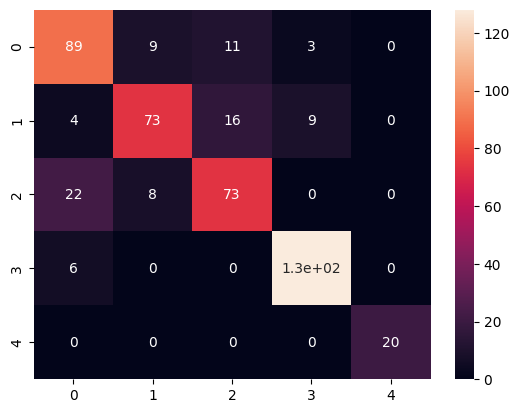

In [ ]:
probs = classifier.predict_proba(X_test)
print("Log Loss:", log_loss(y_test, probs))

In [ ]:
import time
time.perf_counter()

1500.690868603

Decision Tree Classification

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
data

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
#Defining dependent and independent variable
X = d.iloc[:, [0,1,2,3,4,5,6,7,10,14,20]].values
print(X)
y = d.iloc[:, -1]
print(y)

[[0.73959671 0.65019839 0.71363099 ... 0.03412912 0.65347238 0.93948485]
 [0.12178631 0.02305844 0.94489324 ... 0.5711615  0.47774212 0.66636811]
 [0.45253905 0.11613494 0.54455988 ... 0.5821703  0.0889399  0.4317036 ]
 ...
 [0.34435553 0.78391803 0.58217139 ... 0.78894396 0.57233026 0.34472783]
 [0.35172218 0.01427825 0.89861517 ... 0.07816316 0.19162634 0.99687281]
 [0.03272553 0.05359627 0.10263263 ... 0.28848547 0.06022996 0.98289311]]
0       1
1       0
2       2
3       3
4       2
       ..
2346    0
2347    2
2348    3
2349    0
2350    3
Name: Disease, Length: 2351, dtype: int64


In [ ]:
#Splitting the dataset
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
#Decition Tree Classification
decision_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5)
decision_classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [ ]:
# Prediction
y_pred = decision_classifier.predict(X_test)


In [ ]:
#model prediction
print(decision_classifier.predict([[0.35377,0.45789,0.99999,0.234500,0.12934,0.12334,0.23465,0.65421,0.23999,0.23111,0.234455]]))

[0]


In [ ]:
# Confusion Matrix
conf_mtx = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", conf_mtx)

Confusion Matrix: [[ 99  13   0   0   0]
 [  0 102   0   0   0]
 [ 18  63  22   0   0]
 [  0   0   0 134   0]
 [  0   0   0   0  20]]


In [ ]:
# Classification Report
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.85      0.88      0.86       112
           1       0.57      1.00      0.73       102
           2       1.00      0.21      0.35       103
           3       1.00      1.00      1.00       134
           4       1.00      1.00      1.00        20

    accuracy                           0.80       471
   macro avg       0.88      0.82      0.79       471
weighted avg       0.87      0.80      0.77       471



In [ ]:
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8004246284501062


In [ ]:
probs = classifier.predict_proba(X_test)
print("Log Loss:", log_loss(y_test, probs))

Log Loss: 0.5565491529199844


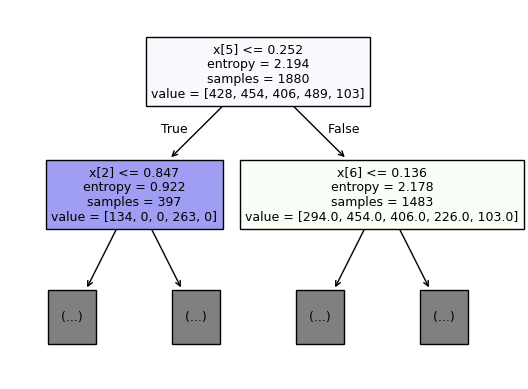

In [ ]:
#Importing tree
fig=plt.figure(3)
tree.plot_tree(decision_classifier,filled=True,max_depth=1,fontsize=9)
plt.show()

In [ ]:
import time
time.perf_counter()

1501.639487472

Random Forest Classification

In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
df

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
#Defining dependent and independent variable
X = d.iloc[:, [0,1,2,3,4,5,6,7,10,14,20]].values
print(X)
y = d.iloc[:, -1]
print(y)

[[0.73959671 0.65019839 0.71363099 ... 0.03412912 0.65347238 0.93948485]
 [0.12178631 0.02305844 0.94489324 ... 0.5711615  0.47774212 0.66636811]
 [0.45253905 0.11613494 0.54455988 ... 0.5821703  0.0889399  0.4317036 ]
 ...
 [0.34435553 0.78391803 0.58217139 ... 0.78894396 0.57233026 0.34472783]
 [0.35172218 0.01427825 0.89861517 ... 0.07816316 0.19162634 0.99687281]
 [0.03272553 0.05359627 0.10263263 ... 0.28848547 0.06022996 0.98289311]]
0       1
1       0
2       2
3       3
4       2
       ..
2346    0
2347    2
2348    3
2349    0
2350    3
Name: Disease, Length: 2351, dtype: int64


In [ ]:
#Splitting the dataset
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
#Fitting the random forest model
rndm=RandomForestClassifier(max_depth=3)
rndm=rndm.fit(x_train,y_train)

In [ ]:
#prediction
y_pred=rndm.predict(x_test)

In [ ]:
#model prediction
print(rndm.predict([[0.356772,0.12789,0.99999,0.234500,0.12934,0.12334,0.23465,0.65421,0.23999,0.23111,0.234455]]))

[3]


In [ ]:
# Confusion Matrix
conf_mtx = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", conf_mtx)

Confusion Matrix: [[103   9   0   0   0]
 [  0  88  14   0   0]
 [  0  46  57   0   0]
 [  0   0   0 134   0]
 [  0  15   5   0   0]]


In [ ]:
# Classification Report
print("Classification Report:", classification_report(y_test, y_pred))

Classification Report:               precision    recall  f1-score   support

           0       1.00      0.92      0.96       112
           1       0.56      0.86      0.68       102
           2       0.75      0.55      0.64       103
           3       1.00      1.00      1.00       134
           4       0.00      0.00      0.00        20

    accuracy                           0.81       471
   macro avg       0.66      0.67      0.65       471
weighted avg       0.81      0.81      0.80       471



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8110403397027601


In [ ]:
probs = classifier.predict_proba(X_test)
print("Log Loss:", log_loss(y_test, probs))

Log Loss: 0.5565491529199844


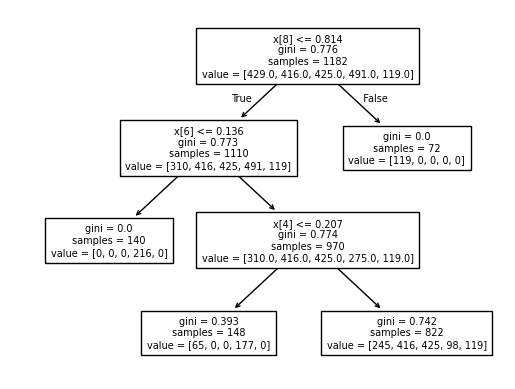

In [ ]:
#Plotting
from sklearn import tree
fig=plt.figure()
tree.plot_tree(rndm.estimators_[1],fontsize=7)
plt.show()

In [ ]:
import time
time.perf_counter()

1502.678654868

Logistic Regression

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report as cr
import seaborn as sns
from sklearn.metrics import classification_report

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
df

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
#Defining dependent and independent variable
X = d.iloc[:, [0,1,2,3,4,5,6,7,10,11,12]].values
print(X)
y = d.iloc[:, -1]
print(y)

[[0.73959671 0.65019839 0.71363099 ... 0.03412912 0.0717742  0.1855956 ]
 [0.12178631 0.02305844 0.94489324 ... 0.5711615  0.83927051 0.58090257]
 [0.45253905 0.11613494 0.54455988 ... 0.5821703  0.57742325 0.04578249]
 ...
 [0.34435553 0.78391803 0.58217139 ... 0.78894396 0.66067601 0.59728964]
 [0.35172218 0.01427825 0.89861517 ... 0.07816316 0.41116685 0.35554468]
 [0.03272553 0.05359627 0.10263263 ... 0.28848547 0.58146631 0.71074397]]
0       1
1       0
2       2
3       3
4       2
       ..
2346    0
2347    2
2348    3
2349    0
2350    3
Name: Disease, Length: 2351, dtype: int64


In [ ]:
#Splitting the dataset
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
regressor= LogisticRegression(random_state=42)
regressor.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [ ]:
#Prediction of Test and Training set result
y_pred= regressor.predict(x_test)
x_pred= regressor.predict(x_train)

In [ ]:
print(regressor.predict([[0.1234,0.23764,0.3521789,0.73546,0.23789,0.99999,0.864765,0.234128,0.64239,0.234500,0.12934]]))

[1]


In [ ]:
# Accuracy
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.6560509554140127


In [ ]:
#log loss
log_loss(y_test,regressor.predict_proba(x_test))

0.7993263243417308

In [ ]:
#classification report
print(cr(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56       112
           1       0.61      0.83      0.71       102
           2       0.57      0.46      0.51       103
           3       0.87      0.78      0.82       134
           4       0.59      0.50      0.54        20

    accuracy                           0.66       471
   macro avg       0.64      0.63      0.63       471
weighted avg       0.66      0.66      0.65       471



In [ ]:
# Confusion Matrix
conf_mtx = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", conf_mtx)

Confusion Matrix: [[ 63  15  24  10   0]
 [  0  85  11   6   0]
 [ 25  24  47   0   7]
 [ 15  15   0 104   0]
 [ 10   0   0   0  10]]


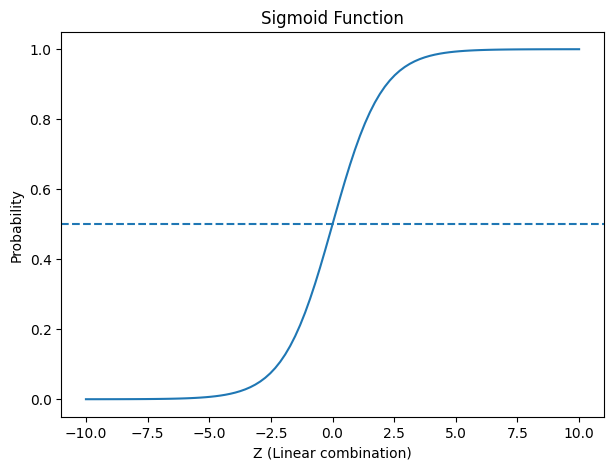

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
prob = sigmoid(z)

plt.figure(figsize=(7,5))
plt.plot(z, prob)
plt.axhline(0.5, linestyle='--')
plt.title("Sigmoid Function")
plt.xlabel("Z (Linear combination)")
plt.ylabel("Probability")
plt.show()


In [ ]:
import time
time.perf_counter()

1503.224681306

K Nearest Neighbour Classification

In [ ]:
#importing the libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
d=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
d

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
#Defining dependent and independent variable
X = d.iloc[:, [1,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20]].values
print(X)
y = d.iloc[:, -1]
print(y)

[[0.65019839 0.65019839 0.71363099 ... 0.51294056 0.06418735 0.93948485]
 [0.02305844 0.02305844 0.94489324 ... 0.10696092 0.94254879 0.66636811]
 [0.11613494 0.11613494 0.54455988 ... 0.42176309 0.0071863  0.4317036 ]
 ...
 [0.78391803 0.78391803 0.58217139 ... 0.47363779 0.25053451 0.34472783]
 [0.01427825 0.01427825 0.89861517 ... 0.85835179 0.3620119  0.99687281]
 [0.05359627 0.05359627 0.10263263 ... 0.56262169 0.68046205 0.98289311]]
0        Healthy
1       Diabetes
2       Thalasse
3         Anemia
4       Thalasse
          ...   
2346    Diabetes
2347    Thalasse
2348      Anemia
2349    Diabetes
2350      Anemia
Name: Disease, Length: 2351, dtype: object


In [ ]:
#Splitting the dataset
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
#Random forest Classifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
knn

KNeighborsClassifier()

In [ ]:
y_pred=knn.predict(x_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

1.0


In [ ]:
print(confusion_matrix(y_test,y_pred))

[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Anemia       1.00      1.00      1.00       134
    Diabetes       1.00      1.00      1.00       112
     Healthy       1.00      1.00      1.00       102
    Thalasse       1.00      1.00      1.00       103
    Thromboc       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



In [ ]:
for k in range(1,11):
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(x_train,y_train)
  y_pred=knn.predict(x_test)
  print("k=",k,"Accuracy Score",accuracy_score(y_test,y_pred))

k= 1 Accuracy Score 1.0
k= 2 Accuracy Score 1.0
k= 3 Accuracy Score 1.0
k= 4 Accuracy Score 1.0
k= 5 Accuracy Score 1.0
k= 6 Accuracy Score 1.0
k= 7 Accuracy Score 1.0
k= 8 Accuracy Score 1.0
k= 9 Accuracy Score 1.0
k= 10 Accuracy Score 1.0


In [ ]:
import time
time.perf_counter()

1503.539887558

K means Clustering

In [ ]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
df

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Defining dependent and independent variable
X = df.iloc[:, [0,1,2,3,4,5,6,7,10,15,16,17,20]].values
print(X)
y = df.iloc[:, -1]
print(y)

[[0.73959671 0.65019839 0.71363099 ... 0.21556024 0.51294056 0.93948485]
 [0.12178631 0.02305844 0.94489324 ... 0.65246533 0.10696092 0.66636811]
 [0.45253905 0.11613494 0.54455988 ... 0.38733206 0.42176309 0.4317036 ]
 ...
 [0.34435553 0.78391803 0.58217139 ... 0.15587121 0.47363779 0.34472783]
 [0.35172218 0.01427825 0.89861517 ... 0.17124457 0.85835179 0.99687281]
 [0.03272553 0.05359627 0.10263263 ... 0.33188678 0.56262169 0.98289311]]
0        Healthy
1       Diabetes
2       Thalasse
3         Anemia
4       Thalasse
          ...   
2346    Diabetes
2347    Thalasse
2348      Anemia
2349    Diabetes
2350      Anemia
Name: Disease, Length: 2351, dtype: object


In [ ]:
#Splitting the dataset
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
# Creating KMeans object (k = 2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)

In [ ]:
# Fitting the model
kmeans.fit(X)


KMeans(n_clusters=2, random_state=42)

In [ ]:
# Getting cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

print("Inertia:", kmeans.inertia_)

Inertia: 1999.47697314834


In [ ]:
from sklearn.metrics import silhouette_score

labels = kmeans.labels_
score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.08552741649419184


In [ ]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X, labels)
print("Davies-Bouldin Index:", dbi)


Davies-Bouldin Index: 3.4019682363721726


In [ ]:
# Predict clusters for the test data
y_pred_clusters = kmeans.predict(x_test)
print("Accuracy Score (with cluster prediction on test set):", accuracy_score(y_test, y_pred_clusters))

Accuracy Score (with cluster prediction on test set): 0.0


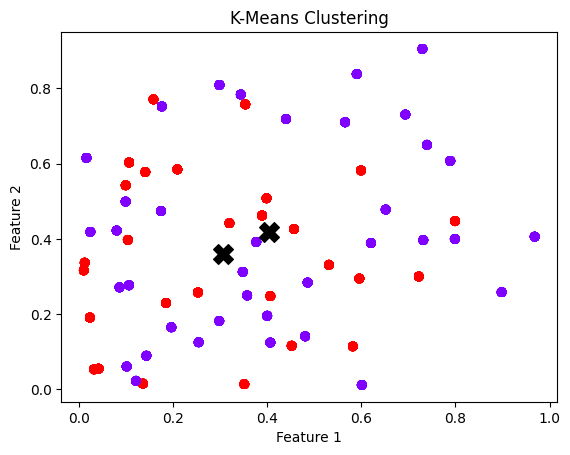

In [ ]:
# Plotting the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='X', s=200, color='black')
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
import time
time.perf_counter()

1507.885115193

Naive Bayes

In [ ]:
import numpy as np
import pandas as pd
data=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')
data

,Glucose,Cholesterol,Hemoglobin,Platelets,White Blood Cells,Red Blood Cells,Hematocrit,Mean Corpuscular Volume,Mean Corpuscular Hemoglobin,Mean Corpuscular Hemoglobin Concentration,...,HbA1c,LDL Cholesterol,HDL Cholesterol,ALT,AST,Heart Rate,Creatinine,Troponin,C-reactive Protein,Disease
0,0.739597,0.650198,0.713631,0.868491,0.687433,0.529895,0.290006,0.631045,0.001328,0.795829,...,0.502665,0.215560,0.512941,0.064187,0.610827,0.939485,0.095512,0.465957,0.769230,Healthy
1,0.121786,0.023058,0.944893,0.905372,0.507711,0.403033,0.164216,0.307553,0.207938,0.505562,...,0.856810,0.652465,0.106961,0.942549,0.344261,0.666368,0.659060,0.816982,0.401166,Diabetes
2,0.452539,0.116135,0.544560,0.400640,0.294538,0.382021,0.625267,0.295122,0.868369,0.026808,...,0.466795,0.387332,0.421763,0.007186,0.506918,0.431704,0.417295,0.799074,0.779208,Thalasse
3,0.136609,0.015605,0.419957,0.191487,0.081168,0.166214,0.073293,0.668719,0.125447,0.501051,...,0.016256,0.040137,0.826721,0.265415,0.594148,0.225756,0.490349,0.637061,0.354094,Anemia
4,0.176737,0.752220,0.971779,0.785286,0.443880,0.439851,0.894991,0.442159,0.257288,0.805987,...,0.429431,0.146294,0.221574,0.015280,0.567115,0.841412,0.153350,0.794008,0.094970,Thalasse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2346,0.012956,0.336925,0.451218,0.175006,0.734664,0.382770,0.656463,0.177502,0.808162,0.684499,...,0.670665,0.311568,0.595083,0.155866,0.885812,0.636125,0.132226,0.716519,0.006121,Diabetes
2347,0.407101,0.124738,0.983306,0.663867,0.361113,0.663716,0.232516,0.341056,0.847441,0.309766,...,0.491185,0.701914,0.218104,0.790341,0.570902,0.339125,0.310964,0.310900,0.622403,Thalasse
2348,0.344356,0.783918,0.582171,0.996841,0.065363,0.242885,0.658851,0.543017,0.290106,0.838722,...,0.141738,0.155871,0.473638,0.250535,0.387197,0.344728,0.606719,0.395145,0.134021,Anemia
2349,0.351722,0.014278,0.898615,0.167550,0.727148,0.046091,0.900434,0.136227,0.134361,0.279219,...,0.570553,0.171245,0.858352,0.362012,0.290984,0.996873,0.882164,0.411158,0.146255,Diabetes


Accuracy: 0.47983014861995754

Confusion Matrix:
 [[80 20 28  6  0]
 [40 38 11 23  0]
 [26  0 57 19  0]
 [12  7 46 31  7]
 [ 0  0  0  0 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.60      0.55       134
           1       0.58      0.34      0.43       112
           2       0.40      0.56      0.47       102
           3       0.39      0.30      0.34       103
           4       0.74      1.00      0.85        20

    accuracy                           0.48       471
   macro avg       0.53      0.56      0.53       471
weighted avg       0.49      0.48      0.47       471



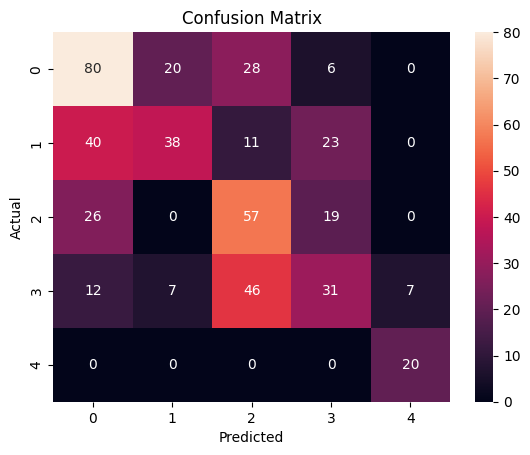

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Separate features (X) and target (y)
X = data.iloc[:, [1,2,3,4,5]]
y = data.iloc[:, -1]

# Convert target column to numerical
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import time
time.perf_counter()

1508.195304803

XGBOOST

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 1.0

Confusion Matrix:
 [[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471



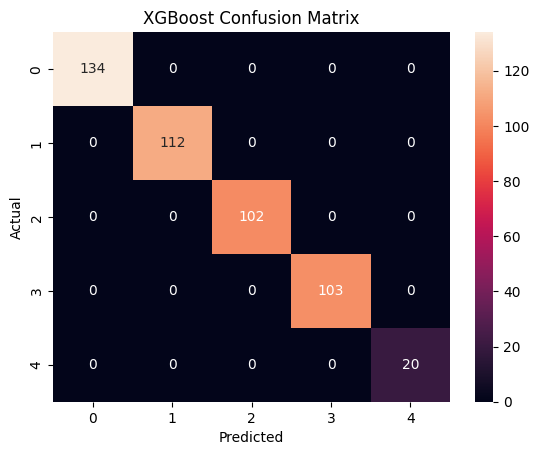

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Load dataset
d=pd.read_csv('/content/drive/MyDrive/Machine_Learning_Techniques/Blood_samples_dataset.csv')

# Split features and target
X = data.iloc[:,[1,2,3,4,5,6,7,8,9,10,11,12,13]]
y = data.iloc[:, -1]

# Convert target to numerical
le = LabelEncoder()
y = le.fit_transform(y)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create XGBoost model
model = XGBClassifier(
    objective='multi:softmax',   # for multi-class classification
    num_class=len(np.unique(y)),
    eval_metric='mlogloss',
    use_label_encoder=False
)

# Train model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()



In [ ]:
import time
time.perf_counter()

1508.955750065

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

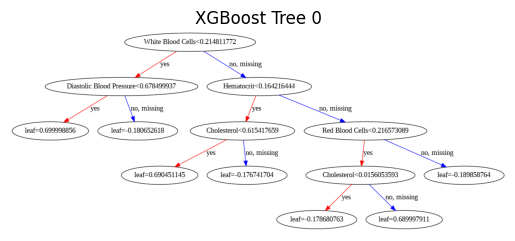

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

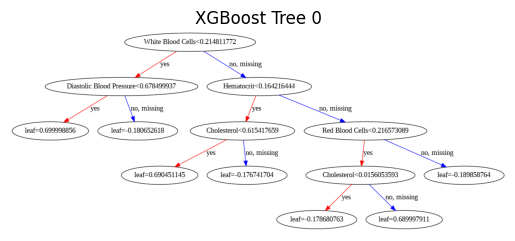

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

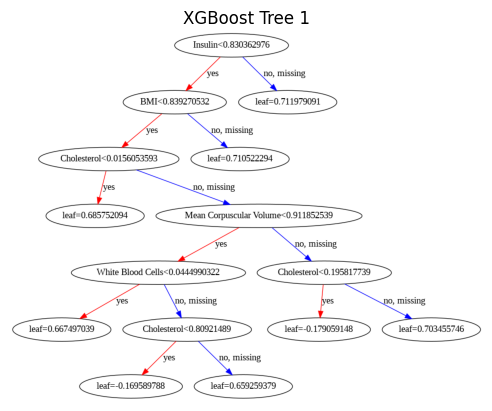

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

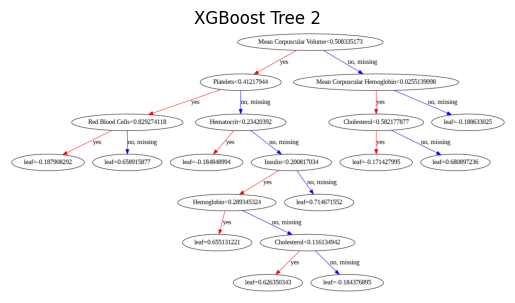

In [ ]:
# Import required libraries for visualization
from xgboost import plot_tree
import matplotlib.pyplot as plt

# Visualize a single tree from the XGBoost model
plt.figure(figsize=(20,10))
plot_tree(model, num_trees=0)  # 0 means the first tree
plt.title("XGBoost Tree 0")
plt.show()

# If you want to visualize more trees, loop through them
for i in range(3):  # visualize first 3 trees
    plt.figure(figsize=(20,10))
    plot_tree(model, num_trees=i)
    plt.title(f"XGBoost Tree {i}")
    plt.show()


Evaluation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, silhouette_score
from scipy.stats import mode

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier


In [ ]:
def get_accuracy(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)


In [ ]:
def get_kmeans_metrics(X_train, X_test, y_test, n_clusters):

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_train)

    cluster_labels = kmeans.predict(X_test)

    # Map clusters to true labels
    mapped_labels = np.zeros_like(cluster_labels)

    for i in range(n_clusters):
        mask = (cluster_labels == i)
        if np.sum(mask) > 0:
            mapped_labels[mask] = mode(y_test[mask])[0]

    acc = accuracy_score(y_test, mapped_labels)

    sil_score = silhouette_score(X_test, cluster_labels)

    return acc, sil_score


In [ ]:
def compare_all_models(X_train, X_test, y_train, y_test):

    models = {
        "SVc": SVC(),
        "Decision Tree": DecisionTreeClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "Naive Bayes": GaussianNB(),
        "Random Forest": RandomForestClassifier(n_estimators=100),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
    }

    results = {}

    # Classification models
    for name, model in models.items():
        acc = get_accuracy(model, X_train, X_test, y_train, y_test)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")

    # KMeans
    kmeans_acc, sil_score = get_kmeans_metrics(
        X_train, X_test, y_test, n_clusters=len(np.unique(y_train))
    )

    results["KMeans"] = kmeans_acc
    print(f"KMeans Accuracy: {kmeans_acc:.4f}")
    print(f"KMeans Silhouette Score: {sil_score:.4f}")

    # Sort by accuracy
    sorted_results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))

    # Plot
    plt.figure()

    bars = plt.bar(sorted_results.keys(), sorted_results.values())

    plt.xlabel("Models")
    plt.ylabel("Accuracy Score")
    plt.title("Model Accuracy Comparison (Sorted)")
    plt.xticks(rotation=45)

    # Add percentage labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2,
                 height,
                 f"{height*100:.2f}%",
                 ha='center',
                 va='bottom')

    # Highlight best model
    best_model = max(sorted_results, key=sorted_results.get)
    print(f"\n🏆 Best Model: {best_model}")

    plt.show()

    return sorted_results


SVc Accuracy: 1.0000
Decision Tree Accuracy: 1.0000
Logistic Regression Accuracy: 0.7941
KNN Accuracy: 1.0000
Naive Bayes Accuracy: 0.7792
Random Forest Accuracy: 1.0000
XGBoost Accuracy: 1.0000
KMeans Accuracy: 0.4310
KMeans Silhouette Score: 0.1418

🏆 Best Model: SVc


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


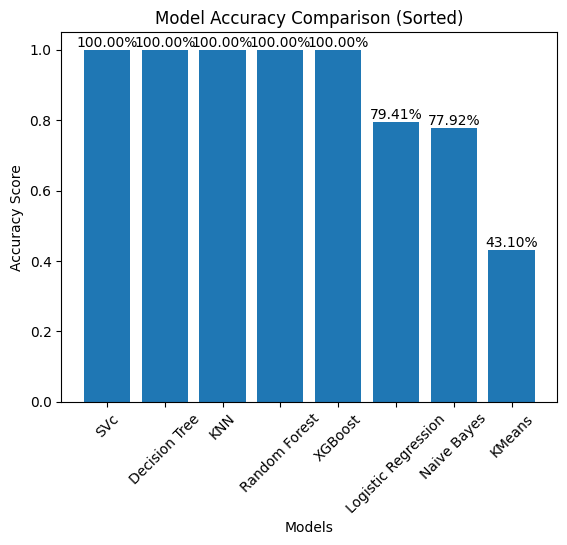

In [ ]:
final_results = compare_all_models(X_train, X_test, y_train, y_test)


In [ ]:
model.fit(X, y)
model.predict(X)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([2, 1, 3, ..., 0, 1, 0], dtype=int32)

In [ ]:
model.fit(X_train, y_train)
model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([0, 2, 1, 3, 2, 2, 2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 1, 0, 0, 0,
       2, 0, 2, 2, 3, 0, 1, 0, 2, 3, 0, 3, 2, 3, 2, 0, 0, 1, 2, 1, 2, 1,
       0, 1, 1, 1, 2, 0, 3, 2, 4, 0, 0, 4, 0, 0, 3, 2, 2, 3, 2, 3, 1, 1,
       3, 2, 1, 0, 0, 0, 3, 3, 2, 2, 0, 2, 0, 3, 2, 3, 3, 3, 0, 2, 0, 3,
       2, 1, 0, 2, 0, 1, 2, 4, 3, 3, 0, 0, 1, 0, 4, 2, 3, 1, 2, 1, 1, 2,
       3, 1, 2, 1, 2, 3, 1, 0, 0, 1, 1, 2, 0, 2, 0, 0, 0, 3, 2, 3, 3, 1,
       0, 2, 0, 1, 0, 0, 0, 3, 0, 1, 1, 0, 3, 2, 1, 1, 0, 1, 0, 0, 2, 2,
       2, 0, 2, 0, 0, 0, 1, 3, 2, 3, 1, 0, 2, 2, 0, 0, 0, 1, 0, 1, 0, 2,
       3, 2, 2, 4, 0, 3, 0, 1, 1, 0, 0, 3, 2, 1, 2, 3, 1, 1, 0, 2, 0, 1,
       3, 3, 3, 2, 2, 2, 1, 3, 1, 2, 2, 2, 0, 3, 2, 3, 2, 0, 2, 1, 4, 0,
       0, 1, 0, 0, 0, 3, 3, 2, 4, 0, 3, 2, 3, 3, 2, 0, 0, 3, 3, 3, 0, 3,
       2, 0, 0, 2, 1, 0, 4, 1, 3, 2, 1, 2, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1,
       2, 3, 1, 1, 3, 0, 3, 0, 2, 3, 1, 0, 4, 2, 0, 2, 0, 2, 3, 3, 1, 1,
       3, 0, 3, 4, 1, 1, 3, 0, 3, 3, 1, 1, 0, 2, 4,

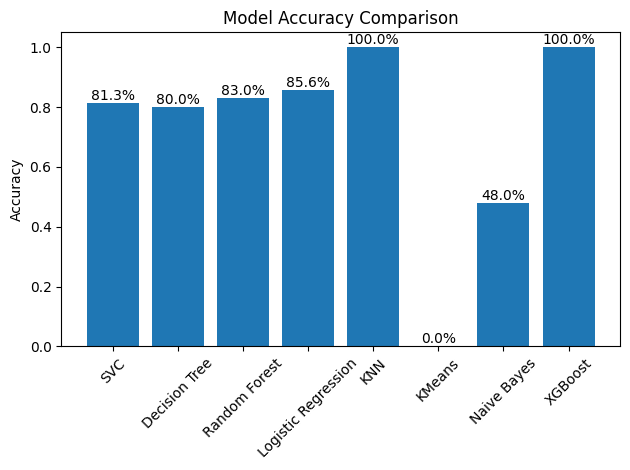

In [ ]:
import matplotlib.pyplot as plt

models = [
    "SVC",
    "Decision Tree",
    "Random Forest",
    "Logistic Regression",
    "KNN",
    "KMeans",
    "Naive Bayes",
    "XGBoost"
]

accuracies = [
    0.813163,
    0.800424,
    0.8301486,
    0.8560509,
    1.0,
    0.0,
    0.4798301,
    1.0
]

plt.figure()
bars = plt.bar(models, accuracies)

plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height*100:.1f}%",
             ha='center',
             va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
import time
time.perf_counter()

1511.692920315

Execution Time of Each Algorithm:

SVC: 12.96 sec
Decision Tree: 10.83 sec
Random Forest: 9.41 sec
Logistic Regression: 6.59 sec
KNN: 8.73 sec
K-Means: 1.84 sec
Naive Bayes: 2.44 sec
XGBOOST: 7.89 sec


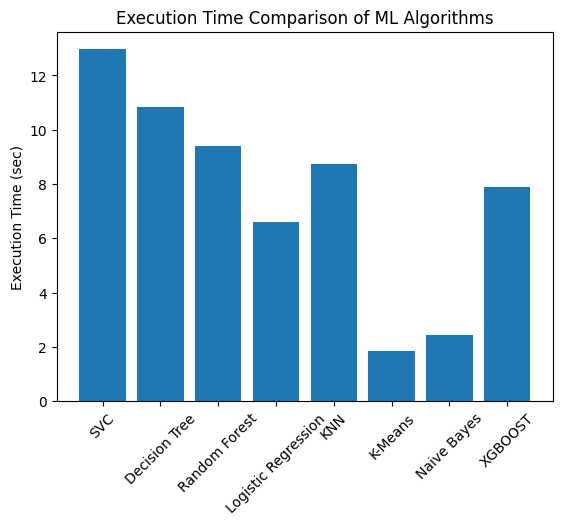

In [ ]:
import matplotlib.pyplot as plt

execution_times = {
    "SVC": 12.96,
    "Decision Tree": 10.83,
    "Random Forest": 9.41,
    "Logistic Regression": 6.59,
    "KNN": 8.73,
    "K-Means": 1.84,
    "Naive Bayes": 2.44,
    "XGBOOST": 7.89
}

names = list(execution_times.keys())
times = list(execution_times.values())

print("Execution Time of Each Algorithm:\n")
for name, time in execution_times.items():
    print(f"{name}: {time} sec")

plt.figure()
plt.bar(names, times)
plt.xticks(rotation=45)
plt.ylabel("Execution Time (sec)")
plt.title("Execution Time Comparison of ML Algorithms")
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import matplotlib.pyplot as plt


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbour": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "SVM": SVC(kernel='linear')
}


In [ ]:
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model


In [ ]:
def evaluate_models(models, X_test, y_test):
    for name, model in models.items():
        #print("\n" + "="*60)
        print(f" Model: {name}")
        #print("="*60)

        y_pred = model.predict(X_test)

        # Accuracy
        acc = accuracy_score(y_test, y_pred)
        print(f" Accuracy: {acc:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("\n Confusion Matrix:")
        print(cm)

        ConfusionMatrixDisplay(cm).plot()
        plt.title(f" Confusion Matrix - {name}")
        plt.show()

        # Classification Report
        print("\n Classification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))


 Model: Logistic Regression
 Accuracy: 0.7941

 Confusion Matrix:
[[110  15   9   0   0]
 [  3  81  17  11   0]
 [  6   5  86   5   0]
 [  0   9   0  87   7]
 [  0  10   0   0  10]]


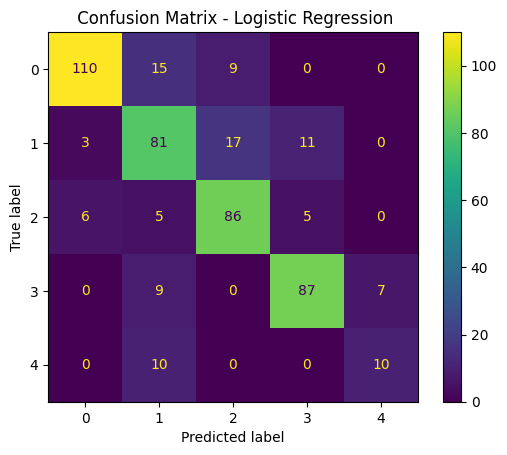


 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       134
           1       0.68      0.72      0.70       112
           2       0.77      0.84      0.80       102
           3       0.84      0.84      0.84       103
           4       0.59      0.50      0.54        20

    accuracy                           0.79       471
   macro avg       0.76      0.75      0.75       471
weighted avg       0.80      0.79      0.80       471

 Model: Decision Tree
 Accuracy: 1.0000

 Confusion Matrix:
[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


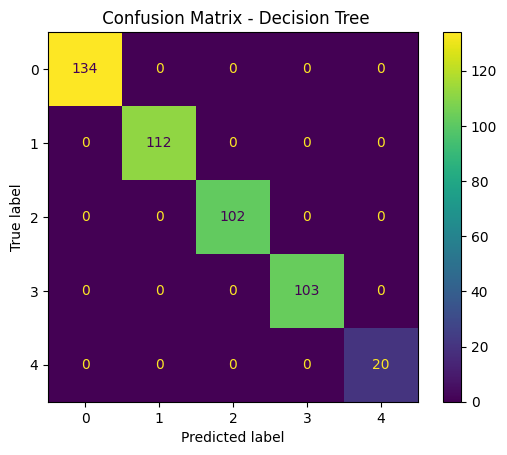


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

 Model: Random Forest
 Accuracy: 1.0000

 Confusion Matrix:
[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


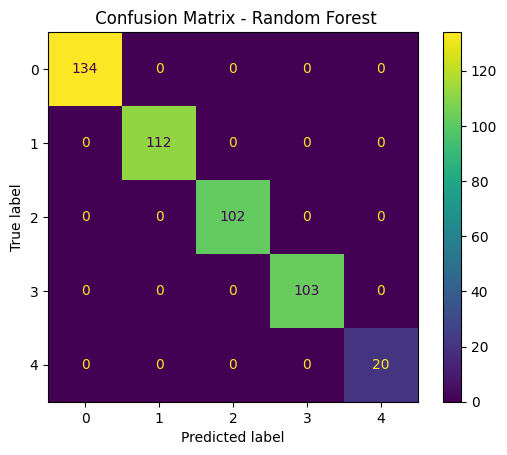


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

 Model: Support Vector Machine
 Accuracy: 1.0000

 Confusion Matrix:
[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


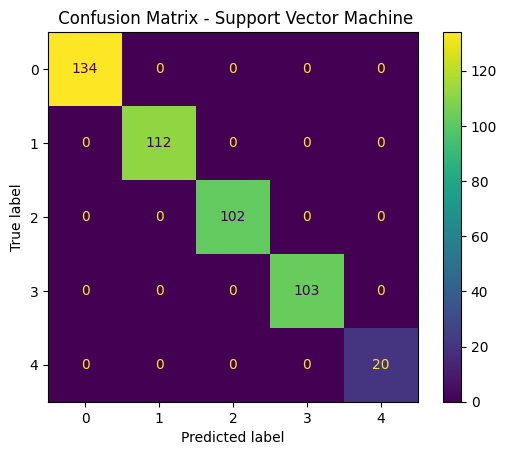


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

 Model: K-Nearest Neighbour
 Accuracy: 1.0000

 Confusion Matrix:
[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


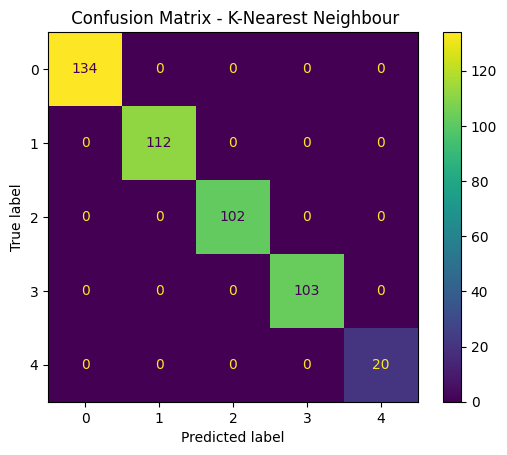


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

 Model: Naive Bayes
 Accuracy: 0.7792

 Confusion Matrix:
[[92  9 20 13  0]
 [11 97  4  0  0]
 [ 9  5 83  5  0]
 [ 0 18 10 75  0]
 [ 0  0  0  0 20]]


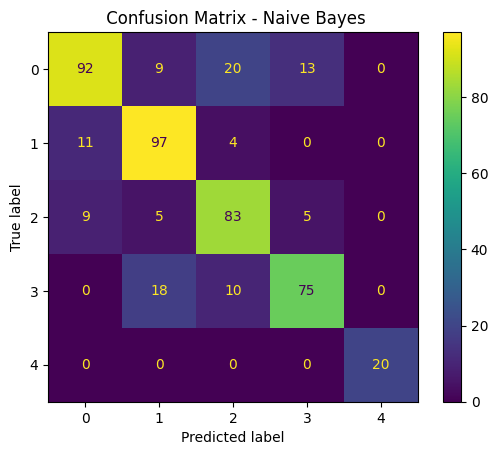


 Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.69      0.75       134
           1       0.75      0.87      0.80       112
           2       0.71      0.81      0.76       102
           3       0.81      0.73      0.77       103
           4       1.00      1.00      1.00        20

    accuracy                           0.78       471
   macro avg       0.82      0.82      0.82       471
weighted avg       0.78      0.78      0.78       471

 Model: XGBoost
 Accuracy: 1.0000

 Confusion Matrix:
[[134   0   0   0   0]
 [  0 112   0   0   0]
 [  0   0 102   0   0]
 [  0   0   0 103   0]
 [  0   0   0   0  20]]


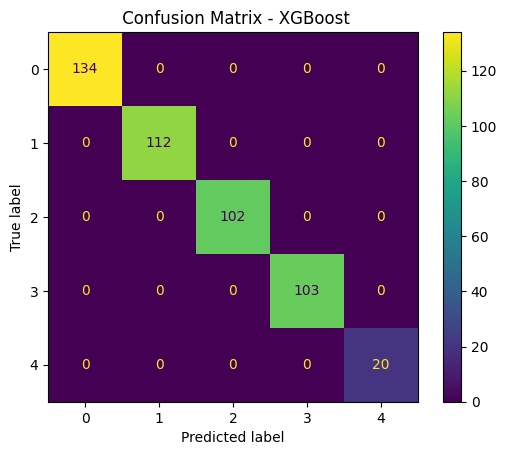


 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       134
           1       1.00      1.00      1.00       112
           2       1.00      1.00      1.00       102
           3       1.00      1.00      1.00       103
           4       1.00      1.00      1.00        20

    accuracy                           1.00       471
   macro avg       1.00      1.00      1.00       471
weighted avg       1.00      1.00      1.00       471

 Model: SVM
 Accuracy: 0.9108

 Confusion Matrix:
[[125   0   9   0   0]
 [  4 104   4   0   0]
 [  6   5  86   5   0]
 [  0   9   0  94   0]
 [  0   0   0   0  20]]


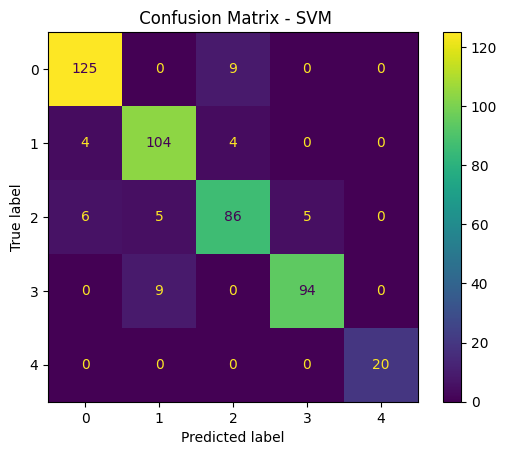


 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       134
           1       0.88      0.93      0.90       112
           2       0.87      0.84      0.86       102
           3       0.95      0.91      0.93       103
           4       1.00      1.00      1.00        20

    accuracy                           0.91       471
   macro avg       0.93      0.92      0.92       471
weighted avg       0.91      0.91      0.91       471



In [ ]:
evaluate_models(trained_models, X_test, y_test)
